# Stats

some double checking of bootstrapping p-values, and comparing with Mann-Whitney

In [1]:
import numpy as np 
import scipy.stats
import sys
from matplotlib import pyplot as plt
import importlib

sys.path.append('/home/nuttidalab/Documents/spikeRNN/utils/')
from bootstrap_method import *

In [2]:
good_erpac = np.load('good_erpac.npy')
good_erpac = np.array(good_erpac)
bad_erpac = np.load('bad_erpac.npy')
bad_erpac = np.array(bad_erpac)

print(good_erpac.shape)
print(bad_erpac.shape)

(41, 168)
(26, 168)


In [3]:
freqs = np.arange(31, 199, 1)

In [4]:
# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

In [15]:
good_erpac_delay = np.mean(good_erpac, axis=0)
bad_erpac_delay = np.mean(bad_erpac, axis=0)
good_erpac_delay_sem = np.std(good_erpac, axis=0)/np.sqrt(good_erpac.shape[0])
bad_erpac_delay_sem = np.std(bad_erpac, axis=0)/np.sqrt(bad_erpac.shape[0])

# bootstrap
good_avg, good_CI, bad_avg, bad_CI, diff_avg, diff_CI, pdiff = fnc_time_bootstrap_optimized_retX(good_erpac, bad_erpac, 
                                                                                            nboot, CI_int, n_jobs=10, random_seed=random_seed)
x_vector = freqs
significant_timepoints = x_vector[pdiff < 0.05]

In [7]:
good_avg.shape

(168, 1000)

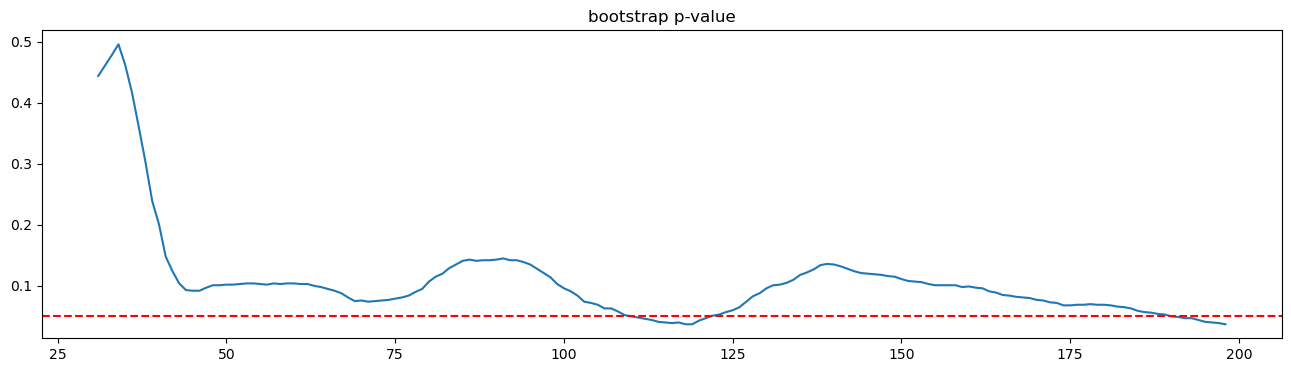

In [14]:
plt.figure(figsize=(16,4))
plt.plot(freqs, pdiff)
plt.axhline(0.05, color='r', linestyle='--')
plt.title('bootstrap p-value')
plt.show()

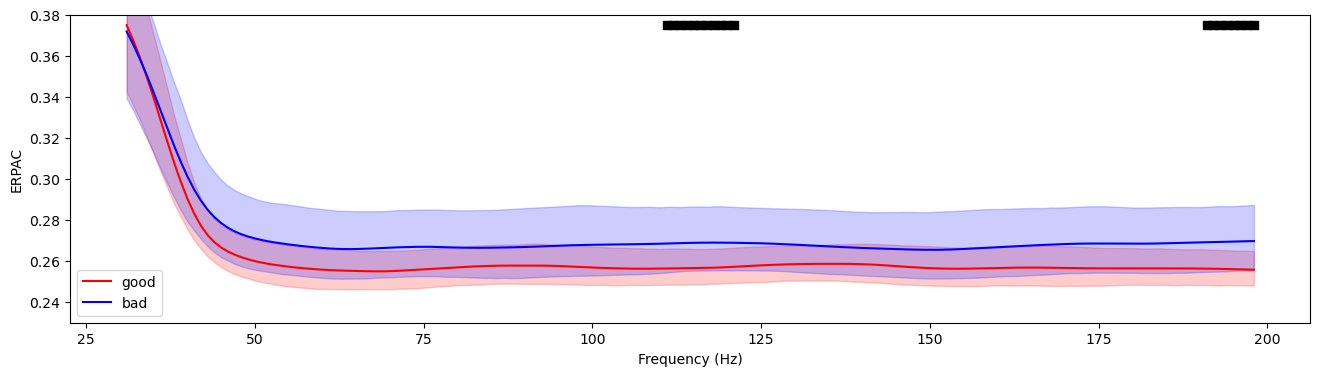

In [8]:
plt.figure(figsize=(16,4))
plt.plot(freqs, np.mean(good_avg, axis=1), label='good', color='r')
plt.plot(freqs, np.mean(bad_avg, axis=1), label='bad', color='b')
plt.fill_between(freqs, good_CI[:,0], good_CI[:,1], color='r', alpha=.2)
plt.fill_between(freqs, bad_CI[:,0], bad_CI[:,1], color='b', alpha=.2)
plt.ylim([.23,.38])
plt.scatter(significant_timepoints, np.zeros_like(significant_timepoints)+.375, color='k', label='_nolegend_', marker='s')
plt.xlabel('Frequency (Hz)')
plt.ylabel('ERPAC')
plt.legend()
plt.show()

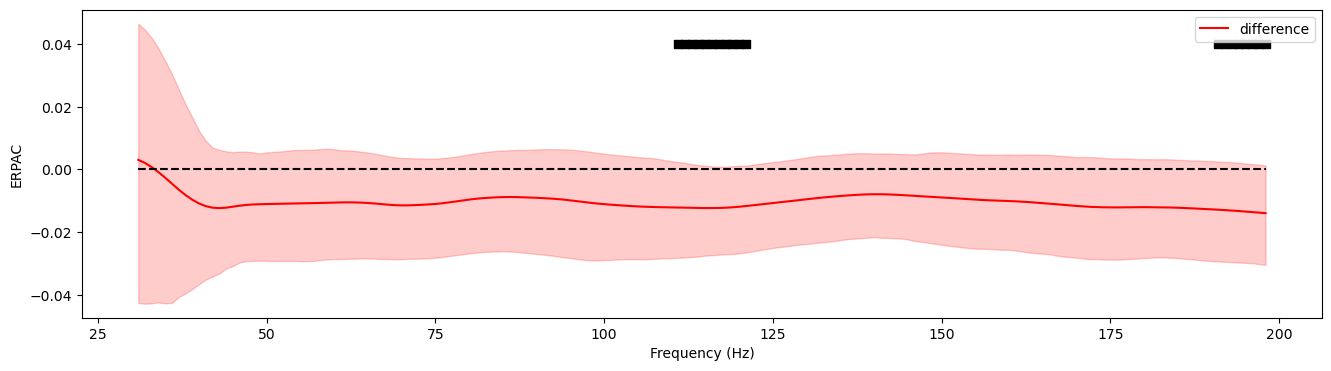

In [11]:
plt.figure(figsize=(16,4))
plt.plot(freqs, np.nanmean(diff_avg, axis=1), label='difference', color='r')
plt.fill_between(freqs, diff_CI[:,0], diff_CI[:,1], color='r', alpha=.2)
plt.hlines(0, freqs[0], freqs[-1], color='k', linestyle='--')
plt.scatter(significant_timepoints, np.zeros_like(significant_timepoints)+.04, color='k', label='_nolegend_', marker='s')
plt.xlabel('Frequency (Hz)')
plt.ylabel('ERPAC')
plt.legend()
plt.show()

## Mann-Whitney

In [20]:
# calculate mann-whitney

p_vals = np.zeros(len(freqs))
for i, freq in enumerate(freqs):
    stat, p = scipy.stats.mannwhitneyu(good_erpac[:,i], bad_erpac[:,i])
    p_vals[i] = p

sig = x_vector[p_vals < 0.05]

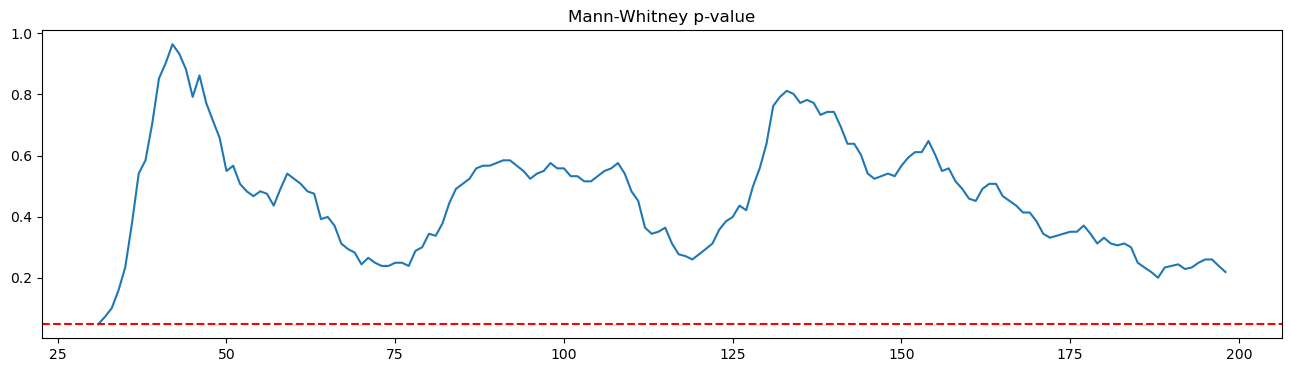

In [21]:
plt.figure(figsize=(16,4))
plt.plot(freqs, p_vals)
plt.axhline(0.05, color='r', linestyle='--')
plt.title('Mann-Whitney p-value')
plt.show()

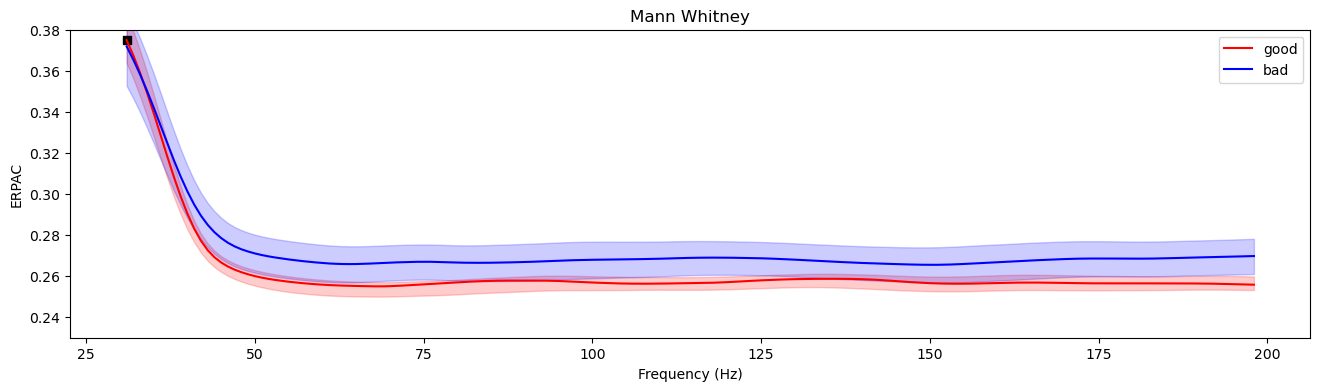

In [22]:
plt.figure(figsize=(16,4))
plt.plot(freqs, np.mean(good_avg, axis=1), label='good', color='r')
plt.plot(freqs, np.mean(bad_avg, axis=1), label='bad', color='b')

plt.fill_between(freqs, good_erpac_delay-good_erpac_delay_sem, good_erpac_delay+good_erpac_delay_sem, color='r', alpha=.2)
plt.fill_between(freqs, bad_erpac_delay-bad_erpac_delay_sem, bad_erpac_delay+bad_erpac_delay_sem, color='b', alpha=.2)
# plt.fill_between(freqs, good_CI[:,0], good_CI[:,1], color='r', alpha=.2)
# plt.fill_between(freqs, bad_CI[:,0], bad_CI[:,1], color='b', alpha=.2)
plt.ylim([.23,.38])
plt.scatter(sig, np.zeros_like(sig)+.375, color='k', label='_nolegend_', marker='s')
plt.xlabel('Frequency (Hz)')
plt.ylabel('ERPAC')
plt.title('Mann Whitney')
plt.legend()
plt.show()

solid line is the mean, not the resampled

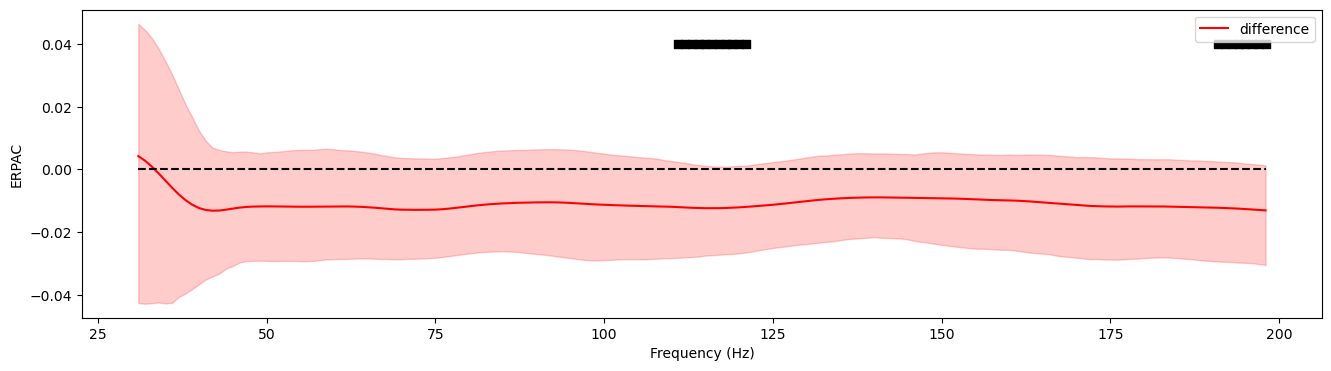

In [9]:
plt.figure(figsize=(16,4))
plt.plot(freqs, good_erpac_delay - bad_erpac_delay, label='difference', color='r')
plt.fill_between(freqs, diff_CI[:,0], diff_CI[:,1], color='r', alpha=.2)
plt.hlines(0, freqs[0], freqs[-1], color='k', linestyle='--')
plt.scatter(significant_timepoints, np.zeros_like(significant_timepoints)+.04, color='k', label='_nolegend_', marker='s')
plt.xlabel('Frequency (Hz)')
plt.ylabel('ERPAC')
plt.legend()
plt.show()

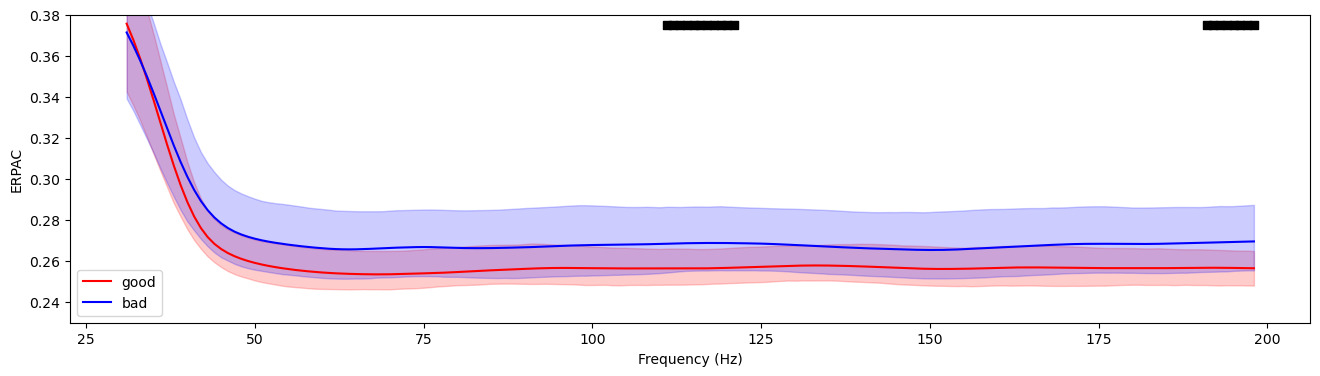

In [9]:
plt.figure(figsize=(16,4))
plt.plot(freqs, good_erpac_delay, label='good', color='r')
plt.plot(freqs, bad_erpac_delay, label='bad', color='b')
plt.fill_between(freqs, good_CI[:,0], good_CI[:,1], color='r', alpha=.2)
plt.fill_between(freqs, bad_CI[:,0], bad_CI[:,1], color='b', alpha=.2)
plt.ylim([.23,.38])
plt.scatter(significant_timepoints, np.zeros_like(significant_timepoints)+.375, color='k', label='_nolegend_', marker='s')
plt.xlabel('Frequency (Hz)')
plt.ylabel('ERPAC')
plt.legend()